# Linear Regression Training - FC110554 Chandira

Train and evaluate a Linear Regression model to predict `Global_Sales` from engineered and encoded features.


In [1]:
# Step 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import joblib


In [2]:
# Step 2: Load cleaned data
cleaned_path = "../../src/data/processed/fc110554_cleaned_vgsales.csv"
df = pd.read_csv(cleaned_path)
print(df.shape)
df.head()


(9769, 77)


,Name,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,...,Publisher_Vivendi Games,Publisher_Warner Bros. Interactive Entertainment,Publisher_Zoo Digital Publishing,Rating_E,Rating_E10+,Rating_EC,Rating_K-A,Rating_M,Rating_RP,Rating_T
0,Wii Sports,2006,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8.0,...,False,False,False,True,False,False,False,False,False,False
1,Mario Kart Wii,2008,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,...,False,False,False,True,False,False,False,False,False,False
2,Wii Sports Resort,2009,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8.0,...,False,False,False,True,False,False,False,False,False,False
3,New Super Mario Bros.,2006,11.28,9.14,6.50,2.88,29.80,89.0,65.0,8.5,...,False,False,False,True,False,False,False,False,False,False
4,Wii Play,2006,13.96,9.18,2.93,2.84,28.92,58.0,41.0,6.6,...,False,False,False,True,False,False,False,False,False,False


In [3]:
# Step 3: Features and target
# Drop obviously non-feature text columns if present
X = df.drop(columns=['Global_Sales'])
if 'Name' in X.columns:
    X = X.drop(columns=['Name'])

y = df['Global_Sales']

print('Features:', X.shape, 'Target:', y.shape)


Features: (9769, 75) Target: (9769,)


In [4]:
# Step 4: Train/Val/Test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(X_train.shape, X_val.shape, X_test.shape)


(6838, 75) (1465, 75) (1466, 75)


In [5]:
# Step 5: Ensure numeric features only (safety)
X_train = X_train.select_dtypes(exclude=['object'])
X_val = X_val.select_dtypes(exclude=['object'])
X_test = X_test.select_dtypes(exclude=['object'])

# Align columns across splits
common_cols = X_train.columns
X_val = X_val.reindex(columns=common_cols, fill_value=0)
X_test = X_test.reindex(columns=common_cols, fill_value=0)

print('Numeric feature count:', len(common_cols))


Numeric feature count: 75


In [6]:
# Step 6: Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


In [7]:
# Step 7: Train Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

# Optional cross-validation on training set (negative MSE)
cv_rmse = (-cross_val_score(lin_reg, X_train_scaled, y_train, cv=5, scoring='neg_root_mean_squared_error')).mean()
print(f'CV RMSE (5-fold): {cv_rmse:.4f}')


CV RMSE (5-fold): 0.0059


In [9]:
# Step 8: Evaluate on validation and test sets
def eval_split(X_s, y_true, label):
    y_pred = lin_reg.predict(X_s)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5  # Manual RMSE
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{label} -> RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")
    return y_pred, rmse, mae, r2

_ = eval_split(X_val_scaled, y_val, 'Validation')
y_pred_test, rmse_test, mae_test, r2_test = eval_split(X_test_scaled, y_test, 'Test')



Validation -> RMSE: 0.0059 | MAE: 0.0038 | R2: 1.0000
Test -> RMSE: 0.0058 | MAE: 0.0037 | R2: 1.0000


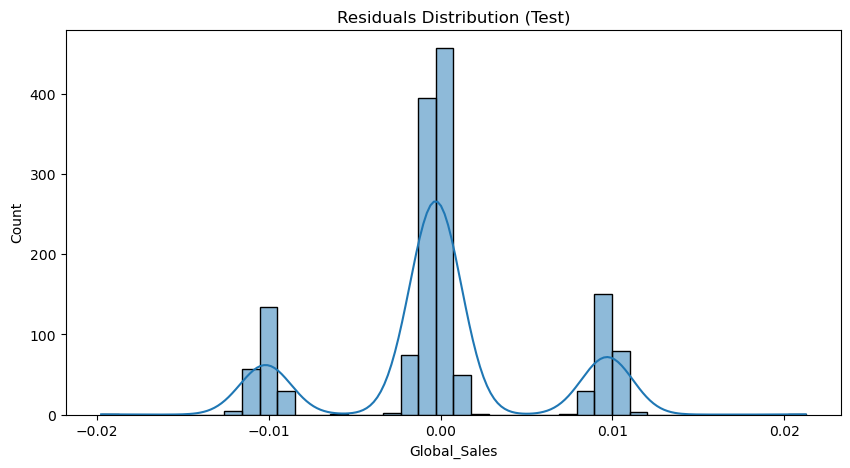

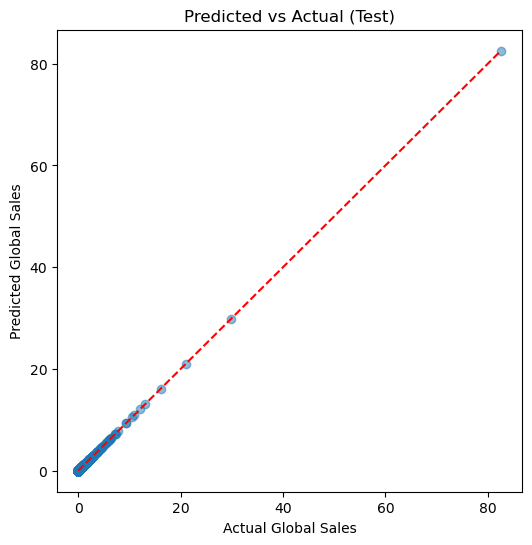

In [10]:
# Step 9: Residual analysis and parity plot
plt.figure(figsize=(10,5))
residuals = y_test - y_pred_test
sns.histplot(residuals, bins=40, kde=True)
plt.title('Residuals Distribution (Test)')
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test, alpha=0.5)
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
plt.plot(lims, lims, 'r--')
plt.xlabel('Actual Global Sales')
plt.ylabel('Predicted Global Sales')
plt.title('Predicted vs Actual (Test)')
plt.show()


In [11]:
# Step 10: Save model and scaler
model_path = "../../models/fc110554_linear_model.pkl"
scaler_path = "../../models/fc110554_scaler.pkl"
joblib.dump(lin_reg, model_path)
joblib.dump(scaler, scaler_path)
print(f"Saved model to {model_path}\nSaved scaler to {scaler_path}")


Saved model to ../../models/fc110554_linear_model.pkl
Saved scaler to ../../models/fc110554_scaler.pkl


In [13]:
# Step 11: Quick metrics from saved artifacts (reproducible)
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# Paths mirror earlier cells
cleaned_path = "../../src/data/processed/fc110554_cleaned_vgsales.csv"
model_path = "../../models/fc110554_linear_model.pkl"
scaler_path = "../../models/fc110554_scaler.pkl"

# Load data and recreate splits exactly as before
df = pd.read_csv(cleaned_path)
X = df.drop(columns=["Global_Sales"])
if "Name" in X.columns:
    X = X.drop(columns=["Name"])  # safety

y = df["Global_Sales"]
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Numeric safety and column alignment
X_train = X_train.select_dtypes(exclude=["object"])
X_val = X_val.select_dtypes(exclude=["object"])
X_test = X_test.select_dtypes(exclude=["object"])
common_cols = X_train.columns
X_val = X_val.reindex(columns=common_cols, fill_value=0)
X_test = X_test.reindex(columns=common_cols, fill_value=0)

# Load artifacts
lin_reg = joblib.load(model_path)
scaler = joblib.load(scaler_path)

# Transform and evaluate
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

for label, Xs, y_true in [("Validation", X_val_s, y_val), ("Test", X_test_s, y_test)]:
    y_pred = lin_reg.predict(Xs)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5  # compatible RMSE
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{label} -> RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")


Validation -> RMSE: 0.0059 | MAE: 0.0038 | R2: 1.0000
Test -> RMSE: 0.0058 | MAE: 0.0037 | R2: 1.0000


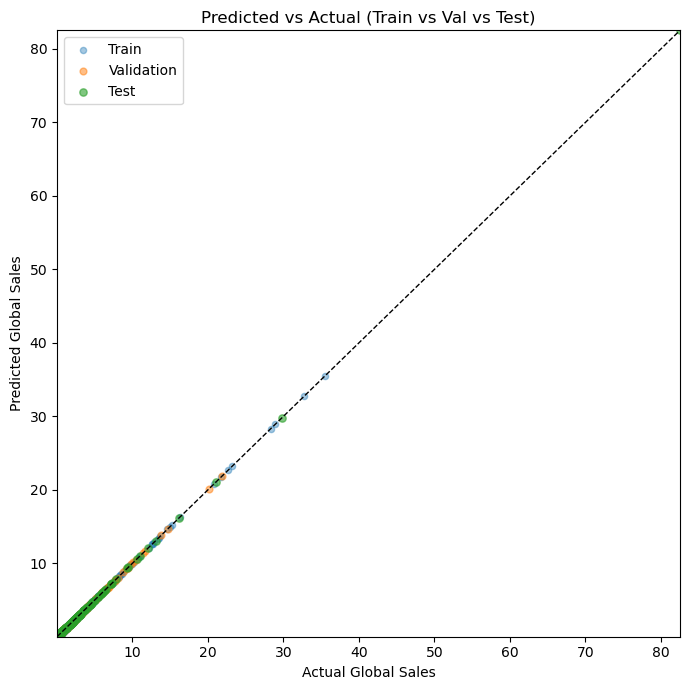

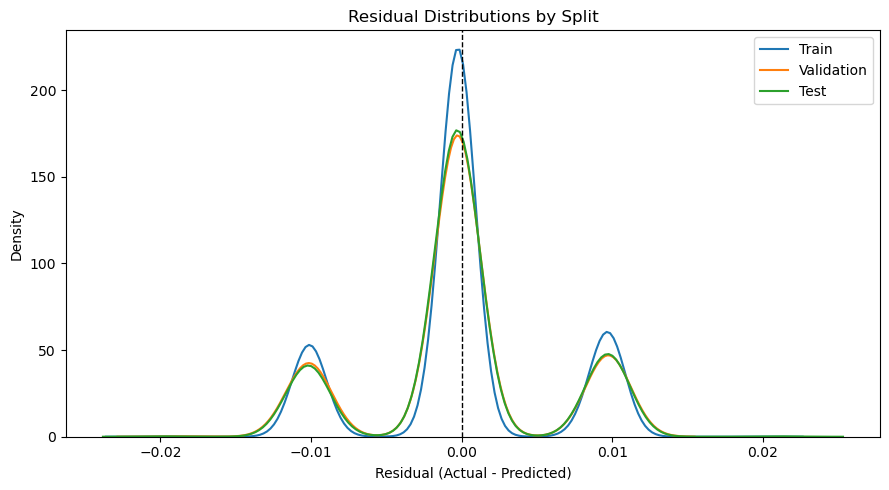

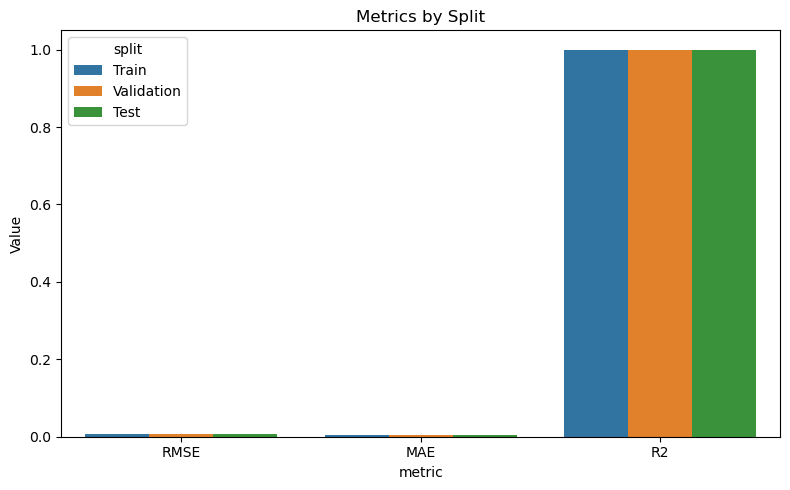

Train: {'RMSE': 0.005788463082657067, 'MAE': 0.0036984344363126557, 'R2': 0.9999835878894222}
Validation: {'RMSE': 0.005856422144095859, 'MAE': 0.0037565483521851462, 'R2': 0.9999847703035011}
Test: {'RMSE': 0.005809679143647227, 'MAE': 0.0036984149147378533, 'R2': 0.9999951088318062}


In [16]:
# Step 12: Visualize Train vs Validation vs Test performance
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# Reload data and artifacts to be self-contained
cleaned_path = "../../src/data/processed/fc110554_cleaned_vgsales.csv"
model_path = "../../models/fc110554_linear_model.pkl"
scaler_path = "../../models/fc110554_scaler.pkl"

df = pd.read_csv(cleaned_path)
X = df.drop(columns=["Global_Sales"])
if "Name" in X.columns:
    X = X.drop(columns=["Name"])  # safety

y = df["Global_Sales"]
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Numeric-only and column alignment across splits
X_train = X_train.select_dtypes(exclude=["object"])
X_val = X_val.select_dtypes(exclude=["object"])
X_test = X_test.select_dtypes(exclude=["object"])
common_cols = X_train.columns
X_val = X_val.reindex(columns=common_cols, fill_value=0)
X_test = X_test.reindex(columns=common_cols, fill_value=0)

lin_reg = joblib.load(model_path)
scaler = joblib.load(scaler_path)

X_train_s = scaler.transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

# Predictions
y_pred_train = lin_reg.predict(X_train_s)
y_pred_val = lin_reg.predict(X_val_s)
y_pred_test = lin_reg.predict(X_test_s)

# Metrics helper
def compute_metrics(y_true, y_pred):
    return {
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,  # manual RMSE
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

m_train = compute_metrics(y_train, y_pred_train)
m_val = compute_metrics(y_val, y_pred_val)
m_test = compute_metrics(y_test, y_pred_test)

# 1) Parity plot (Predicted vs Actual) with all splits
plt.figure(figsize=(7, 7))
plt.scatter(y_train, y_pred_train, alpha=0.4, s=20, label="Train", color="#1f77b4")
plt.scatter(y_val, y_pred_val, alpha=0.5, s=24, label="Validation", color="#ff7f0e")
plt.scatter(y_test, y_pred_test, alpha=0.6, s=28, label="Test", color="#2ca02c")
lims = [min(y.min() for y in [y_train, y_val, y_test]), max(y.max() for y in [y_train, y_val, y_test])]
plt.plot(lims, lims, "k--", linewidth=1)
plt.xlim(lims)
plt.ylim(lims)
plt.xlabel("Actual Global Sales")
plt.ylabel("Predicted Global Sales")
plt.title("Predicted vs Actual (Train vs Val vs Test)")
plt.legend()
plt.tight_layout()
plt.show()

# 2) Residual curves (KDE) for each split
plt.figure(figsize=(9, 5))
res_train = y_train - y_pred_train
res_val = y_val - y_pred_val
res_test = y_test - y_pred_test
sns.kdeplot(res_train, label="Train", color="#1f77b4")
sns.kdeplot(res_val, label="Validation", color="#ff7f0e")
sns.kdeplot(res_test, label="Test", color="#2ca02c")
plt.axvline(0, color="k", linestyle="--", linewidth=1)
plt.xlabel("Residual (Actual - Predicted)")
plt.title("Residual Distributions by Split")
plt.legend()
plt.tight_layout()
plt.show()

# 3) Grouped bar chart for RMSE, MAE, R2 across splits
metrics_df = pd.DataFrame([
    {"split": "Train", **m_train},
    {"split": "Validation", **m_val},
    {"split": "Test", **m_test},
])
metrics_long = metrics_df.melt(id_vars="split", var_name="metric", value_name="value")
plt.figure(figsize=(8, 5))
sns.barplot(data=metrics_long, x="metric", y="value", hue="split")
plt.title("Metrics by Split")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

# Print numeric metrics for quick reference
print("Train:", m_train)
print("Validation:", m_val)
print("Test:", m_test)